# 파마리서치 피부과 의약품 처방 데이터 분석
**ATC코드 D11AH (피부염 치료제, 스테로이드 제외) — 서울 시군구별 2020.01 ~ 2024.12**

건강보험심사평가원 ATC코드 4단계 시군구별 처방 데이터를 기반으로  
서울 내 25개 자치구의 처방 수량 및 금액 트렌드를 분석합니다.

In [1]:
# ── 0. 필수 라이브러리 임포트 ─────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 그래프 저장 폴더 생성
OUTPUT_DIR = Path('output_figures')
OUTPUT_DIR.mkdir(exist_ok=True)

print('라이브러리 로드 완료')
print(f'matplotlib {matplotlib.__version__} / pandas {pd.__version__}')

라이브러리 로드 완료
matplotlib 3.10.8 / pandas 3.0.1


In [2]:
# ── 1. 한글 폰트 설정 ──────────────────────────────────────
# macOS: AppleGothic, Linux: NanumGothic 순으로 탐색
def set_korean_font():
    candidates = ['AppleGothic', 'NanumGothic', 'NanumBarunGothic', 'Malgun Gothic']
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = font
            print(f'한글 폰트 설정: {font}')
            return font
    import subprocess, sys
    if sys.platform == 'darwin':
        result = subprocess.run(['fc-list', ':lang=ko', '--format=%{family}\n'],
                                capture_output=True, text=True)
        if result.stdout:
            font = result.stdout.split('\n')[0].split(',')[0].strip()
            plt.rcParams['font.family'] = font
            print(f'한글 폰트(fc-list): {font}')
            return font
    print('경고: 한글 폰트 없음, 기본 폰트 사용')

set_korean_font()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

한글 폰트 설정: AppleGothic


---
## 1. 데이터 로드 및 전처리

In [3]:
# ── 2. Excel 파일 로드 ──────────────────────────────────────
# 헤더가 3행에 걸쳐 있으므로 header=None으로 원시 데이터 로드
RAW_FILE = 'ATC코드4단계의_시군구별_202001_202412.xlsx'

raw = pd.read_excel(RAW_FILE, sheet_name=0, header=None)
print(f'원시 데이터 크기: {raw.shape}')
print(f'  헤더: 0~3행 | 합계: 4행 | 데이터: 5~{raw.shape[0]-1}행 ({raw.shape[0]-5}개 자치구)')

원시 데이터 크기: (30, 110)
  헤더: 0~3행 | 합계: 4행 | 데이터: 5~29행 (25개 자치구)


In [4]:
# ── 3. 컬럼 매핑 — 월 라벨 ↔ 수량/금액 컬럼 인덱스 쌍 ─────
# 2행: 짝수 컬럼에 '20XX년 MM월' 라벨, 해당 컬럼=수량, +1=금액
month_labels = {}
for col_idx, val in raw.iloc[2].items():
    if isinstance(val, str) and '년' in val:
        month_labels[col_idx] = val

# (월라벨, 수량컬럼, 금액컬럼) 오름차순 정렬
month_col_pairs = [
    (label, idx, idx + 1)
    for idx, label in sorted(month_labels.items())
]

print(f'파악된 월 수: {len(month_col_pairs)}개월')
print('처음 3개:', [m[0] for m in month_col_pairs[:3]])
print('마지막 3개:', [m[0] for m in month_col_pairs[-3:]])

파악된 월 수: 53개월
처음 3개: ['2024년 12월', '2024년 11월', '2024년 10월']
마지막 3개: ['2020년 03월', '2020년 02월', '2020년 01월']


In [5]:
# ── 4. Wide → Long 변환 (월별 수량/금액을 세로 구조로 재구성) ─
# 원본 가로 구조(각 월이 별도 컬럼) → 날짜 컬럼 추가 세로 구조
# 데이터가 없는 셀은 NaN 그대로 유지 (fillna 없음)
# 이후 집계 시 skipna=True(pandas 기본값)로 NaN을 자동 제외
data_rows = raw.iloc[5:].copy()  # 헤더/합계 행 제외
data_rows.columns = range(len(data_rows.columns))

records = []
for _, row in data_rows.iterrows():
    for month_label, qty_col, amt_col in month_col_pairs:
        records.append({
            'ATC코드':   row[0],
            'ATC코드명': row[1],
            '시도':      row[2],
            '시군구':    row[3],
            '연월':      month_label,
            '수량':      pd.to_numeric(row[qty_col], errors='coerce'),
            '금액':      pd.to_numeric(row[amt_col], errors='coerce'),
        })

df = pd.DataFrame(records)

# '2020년 01월' → datetime 변환
df['날짜'] = pd.to_datetime(
    df['연월'].str.replace('년 ', '-').str.replace('월', ''),
    format='%Y-%m'
)
df['연도'] = df['날짜'].dt.year
df['월']   = df['날짜'].dt.month

print(f'Long 변환 완료: {df.shape}')
print(f'자치구 수: {df["시군구"].nunique()}')
print(f'기간: {df["날짜"].min().strftime("%Y.%m")} ~ {df["날짜"].max().strftime("%Y.%m")}')
print(f'NaN 수량: {df["수량"].isna().sum()}개  NaN 금액: {df["금액"].isna().sum()}개')
df.head(3)

Long 변환 완료: (1325, 10)
자치구 수: 25
기간: 2020.01 ~ 2024.12
NaN 수량: 0개  NaN 금액: 0개


,ATC코드,ATC코드명,시도,시군구,연월,수량,금액,날짜,연도,월
0,D11AH,"Agents for dermatitis, excluding corticosteroids",서울,강남구,2024년 12월,6155,518923220,2024-12-01,2024,12
1,D11AH,"Agents for dermatitis, excluding corticosteroids",서울,강남구,2024년 11월,5254,472336042,2024-11-01,2024,11
2,D11AH,"Agents for dermatitis, excluding corticosteroids",서울,강남구,2024년 10월,6426,505442556,2024-10-01,2024,10


In [6]:
# ── 5. 기초 통계 요약 ───────────────────────────────────────
# 자치구별 전체 기간 합산 수량/금액 확인
summary = (
    df.groupby('시군구')[['수량', '금액']]
    .sum()
    .sort_values('금액', ascending=False)
    .assign(**{'금액(억원)': lambda x: (x['금액'] / 1e8).round(1)})
)
print('=== 자치구별 전체 기간 처방 합계 ===')
print(summary[['수량', '금액(억원)']].to_string())
print(f'\n전체 합계 — 수량: {summary["수량"].sum():,.0f}개  금액: {summary["금액(억원)"].sum():.1f}억원')

=== 자치구별 전체 기간 처방 합계 ===
          수량  금액(억원)
시군구                 
동작구   421747   179.0
서대문구  226790   151.3
중구    152335   144.9
강남구   255876   130.0
강동구   323261   128.8
송파구   300531   125.9
영등포구  251202   108.2
서초구   165232   100.8
종로구   205367    98.8
동대문구  144560    71.8
노원구   136512    59.1
광진구    82846    51.3
성동구   100745    48.4
용산구    71698    43.2
강서구    97575    31.9
성북구    72893    30.4
은평구   138007    28.8
구로구    80459    24.2
양천구    76836    15.5
중랑구    45732    11.9
마포구    45973     5.6
관악구    40751     4.6
강북구    33504     3.3
금천구    31185     2.2
도봉구    15809     1.7

전체 합계 — 수량: 3,517,426개  금액: 1601.6억원


---
## 2. 서울 구별 전체 기간 처방 금액 합계

그래프 저장 완료: output_figures/fig1_구별_처방금액_합계.png


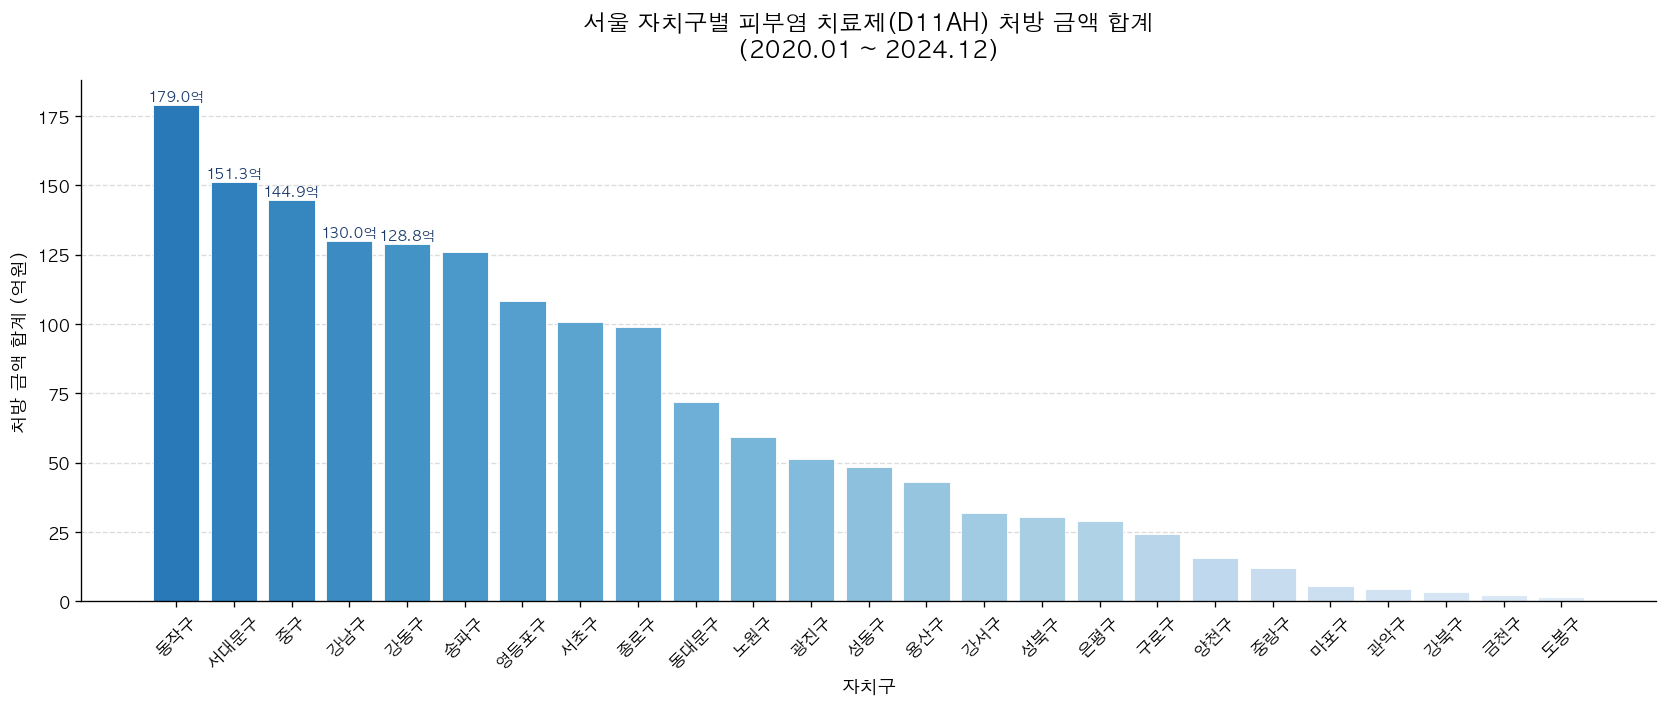

In [7]:
# ── 6. 서울 구별 처방 금액 합계 막대그래프 ─────────────────
# 전체 기간(2020~2024) 구별 금액 합산, 내림차순 정렬
gu_total     = df.groupby('시군구')['금액'].sum().sort_values(ascending=False)
gu_total_eok = gu_total / 1e8  # 억원 단위

fig, ax = plt.subplots(figsize=(14, 6))

# 파마리서치 계열 파란 그라디언트 팔레트
colors = plt.cm.Blues_r(np.linspace(0.28, 0.88, len(gu_total_eok)))
bars = ax.bar(gu_total_eok.index, gu_total_eok.values,
              color=colors, edgecolor='white', linewidth=0.5)

# 상위 5개 구: 막대 위 값 라벨
for i, (bar, val) in enumerate(zip(bars, gu_total_eok.values)):
    if i < 5:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                f'{val:.1f}억', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='#1a3a6b')

ax.set_title('서울 자치구별 피부염 치료제(D11AH) 처방 금액 합계\n(2020.01 ~ 2024.12)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('자치구', fontsize=11)
ax.set_ylabel('처방 금액 합계 (억원)', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.45)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save_path = OUTPUT_DIR / 'fig1_구별_처방금액_합계.png'
plt.savefig(save_path)
print(f'그래프 저장 완료: {save_path}')
plt.show()

---
## 3. 월별 처방 수량 트렌드 (2020 ~ 2024)

그래프 저장 완료: output_figures/fig2_월별_처방_트렌드.png


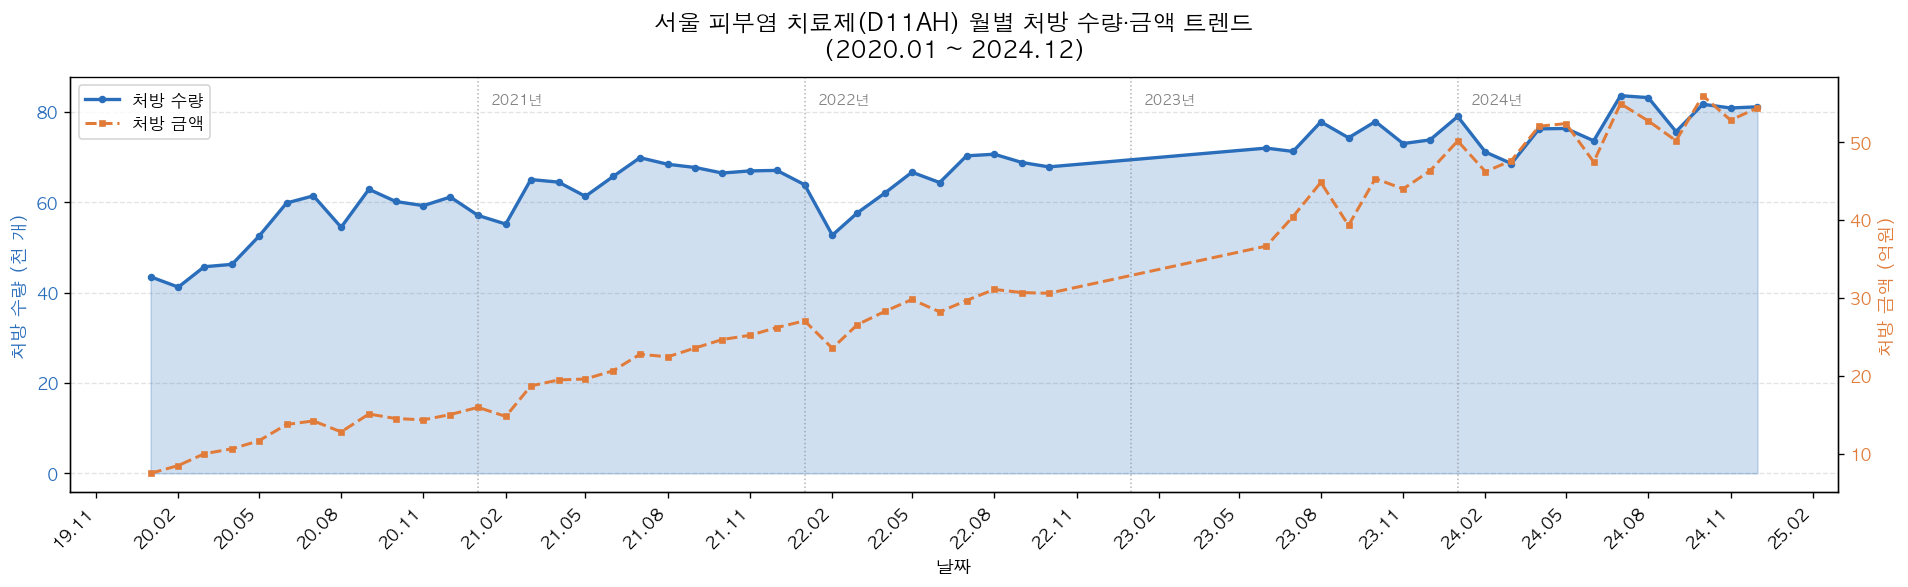

In [8]:
# ── 7. 월별 처방 수량 및 금액 트렌드 — 이중 축 시각화 ───────
# 서울 25개 구 합산 → 월별 시계열 (수량: 왼쪽 y축, 금액: 오른쪽 y축)
monthly_total = (
    df.groupby('날짜')[['수량', '금액']]
    .sum()
    .sort_index()
)

fig, ax1 = plt.subplots(figsize=(16, 5))

# 수량 — 면적 채우기 + 선 (파란 계열)
ax1.fill_between(monthly_total.index, monthly_total['수량'] / 1e3,
                 alpha=0.22, color='#2a6ebb')
ax1.plot(monthly_total.index, monthly_total['수량'] / 1e3,
         color='#2a6ebb', linewidth=2, marker='o', markersize=3.5, label='처방 수량')
ax1.set_ylabel('처방 수량 (천 개)', fontsize=11, color='#2a6ebb')
ax1.tick_params(axis='y', labelcolor='#2a6ebb')

# 금액 — 보조 y축 (주황 계열)
ax2 = ax1.twinx()
ax2.plot(monthly_total.index, monthly_total['금액'] / 1e8,
         color='#e07b39', linewidth=1.8, linestyle='--',
         marker='s', markersize=3, label='처방 금액')
ax2.set_ylabel('처방 금액 (억원)', fontsize=11, color='#e07b39')
ax2.tick_params(axis='y', labelcolor='#e07b39')

# 연도 구분선
for year in range(2021, 2025):
    ax1.axvline(pd.Timestamp(f'{year}-01-01'),
                color='gray', linestyle=':', linewidth=0.9, alpha=0.6)
    ax1.text(pd.Timestamp(f'{year}-01-15'),
             ax1.get_ylim()[1] * 0.96,
             f'{year}년', ha='left', va='top', fontsize=8.5, color='gray')

ax1.set_title('서울 피부염 치료제(D11AH) 월별 처방 수량·금액 트렌드\n(2020.01 ~ 2024.12)',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('날짜', fontsize=11)
ax1.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%y.%m'))
ax1.xaxis.set_major_locator(matplotlib.dates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.yaxis.grid(True, linestyle='--', alpha=0.35)
ax1.set_axisbelow(True)
ax1.spines[['top']].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
save_path = OUTPUT_DIR / 'fig2_월별_처방_트렌드.png'
plt.savefig(save_path)
print(f'그래프 저장 완료: {save_path}')
plt.show()

---
## 4. 계절성 패턴 분석 (월별 평균)

=== 계절성 지수 (연평균 대비 비율, 1.0 = 연평균) ===
        수량     금액
1월   0.924  0.821
2월   0.838  0.778
3월   0.908  0.888
4월   0.950  0.946
5월   0.984  0.983
6월   1.008  0.973
7월   1.069  1.058
8월   1.056  1.054
9월   1.051  1.063
10월  1.059  1.114
11월  1.040  1.105
12월  1.052  1.151


그래프 저장 완료: output_figures/fig3_계절성_패턴.png


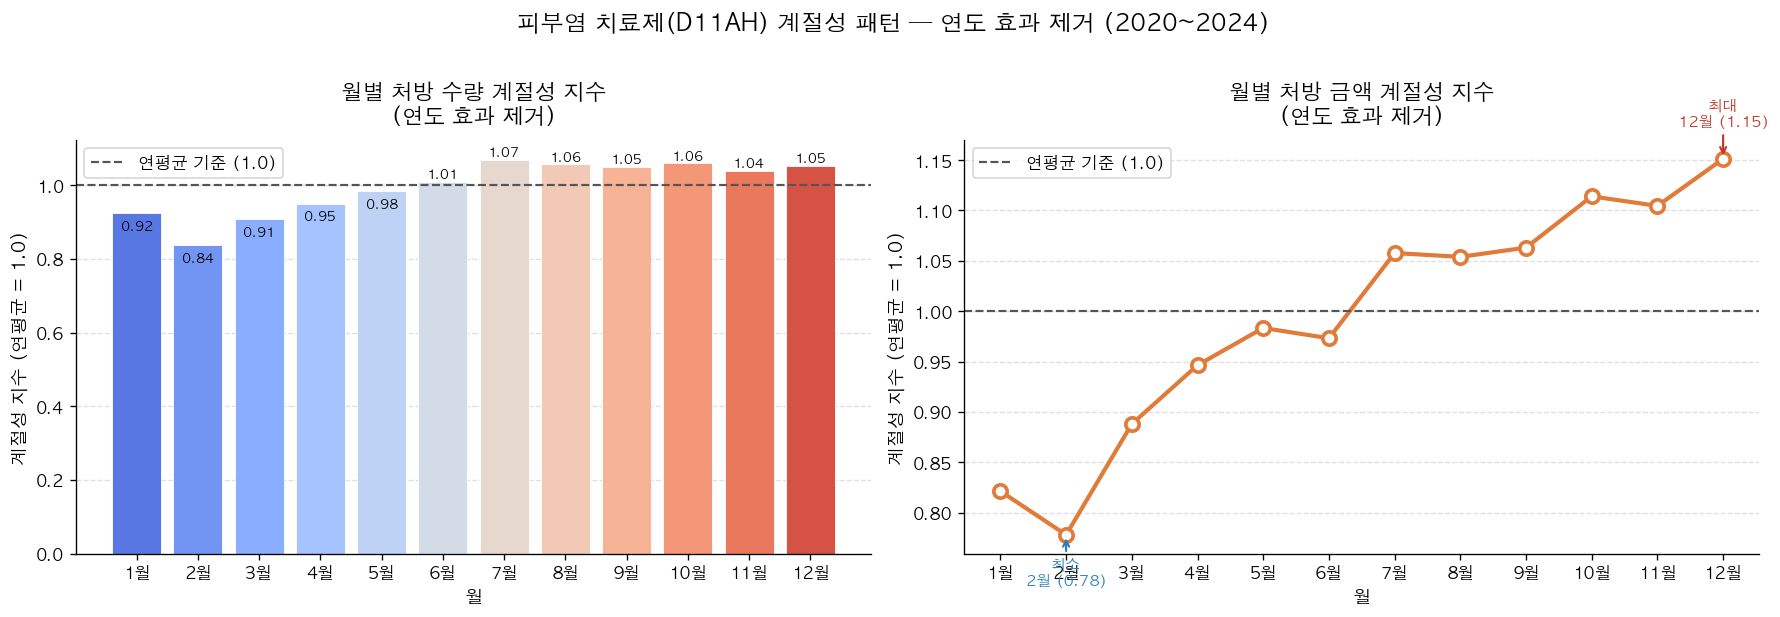

In [9]:
# ── 8. 계절성 패턴 — 연도 효과 제거 후 월별 평균 ────────────────
# 단순 월별 평균은 연간 성장 트렌드(연도 효과)가 혼입되어
# 데이터가 많은 최근 연도에 의해 계절 패턴이 왜곡될 수 있음.
#
# [연도 효과 제거 방법]
# 1. 각 연도별 월평균(해당 연도의 연평균)을 계산
# 2. 각 월 값 ÷ 해당 연도 연평균 → 연평균 대비 비율 (seasonal ratio)
# 3. 연도별로 구한 비율을 월별로 평균 → 순수 계절성 지수

MONTH_KR = {1:'1월',2:'2월',3:'3월',4:'4월',5:'5월',6:'6월',
            7:'7월',8:'8월',9:'9월',10:'10월',11:'11월',12:'12월'}

# 데이터 없는 월(NaN) 제외 후 연도·월 컬럼 추가
mt = (
    monthly_total
    .dropna()                                   # NaN 월 제외 (skipna=True와 동일 효과)
    .assign(연도=lambda x: x.index.year,
            월=lambda x: x.index.month)
)

# 연도별 연평균(해당 연도에 포함된 월만으로 계산)
annual_mean = mt.groupby('연도')[['수량', '금액']].transform('mean')

# 각 월 값을 해당 연도 연평균으로 나눠 비율 계산 (1.0 = 연평균 수준)
mt_ratio = (mt[['수량', '금액']] / annual_mean).assign(월=mt['월'])

# 월별로 비율 평균 → 순수 계절성 지수
seasonal = mt_ratio.groupby('월')[['수량', '금액']].mean(numeric_only=True)
seasonal.index = [MONTH_KR[m] for m in seasonal.index]

print('=== 계절성 지수 (연평균 대비 비율, 1.0 = 연평균) ===')
print(seasonal.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ─ 왼쪽: 수량 계절성 지수 막대그래프 ─
ax = axes[0]
color_seq = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(seasonal)))
bars = ax.bar(seasonal.index, seasonal['수량'],
              color=color_seq, edgecolor='white', linewidth=0.5)
ax.axhline(1.0, color='#555', linestyle='--', linewidth=1.3, label='연평균 기준 (1.0)')
for bar, val in zip(bars, seasonal['수량']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.005 if val >= 1.0 else val - 0.018,
            f'{val:.2f}', ha='center',
            va='bottom' if val >= 1.0 else 'top', fontsize=8)
ax.set_title('월별 처방 수량 계절성 지수\n(연도 효과 제거)', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('월', fontsize=11)
ax.set_ylabel('계절성 지수 (연평균 = 1.0)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)

# ─ 오른쪽: 금액 계절성 지수 꺾은선 ─
ax2 = axes[1]
ax2.plot(seasonal.index, seasonal['금액'],
         color='#e07b39', linewidth=2.5, marker='o', markersize=8,
         markerfacecolor='white', markeredgewidth=2.2)
ax2.axhline(1.0, color='#555', linestyle='--', linewidth=1.3, label='연평균 기준 (1.0)')

# 최대/최소 월 강조
amt_s = seasonal['금액']
max_m, min_m = amt_s.idxmax(), amt_s.idxmin()
ax2.annotate(f'최대\n{max_m} ({amt_s[max_m]:.2f})',
             xy=(max_m, amt_s[max_m]),
             xytext=(0, 20), textcoords='offset points',
             ha='center', fontsize=9, color='#c0392b',
             arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.3))
ax2.annotate(f'최소\n{min_m} ({amt_s[min_m]:.2f})',
             xy=(min_m, amt_s[min_m]),
             xytext=(0, -30), textcoords='offset points',
             ha='center', fontsize=9, color='#2980b9',
             arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.3))
ax2.set_title('월별 처방 금액 계절성 지수\n(연도 효과 제거)', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('월', fontsize=11)
ax2.set_ylabel('계절성 지수 (연평균 = 1.0)', fontsize=11)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=10)

fig.suptitle('피부염 치료제(D11AH) 계절성 패턴 — 연도 효과 제거 (2020~2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_path = OUTPUT_DIR / 'fig3_계절성_패턴.png'
plt.savefig(save_path)
print(f'그래프 저장 완료: {save_path}')
plt.show()

그래프 저장 완료: output_figures/fig4_연도월별_히트맵.png


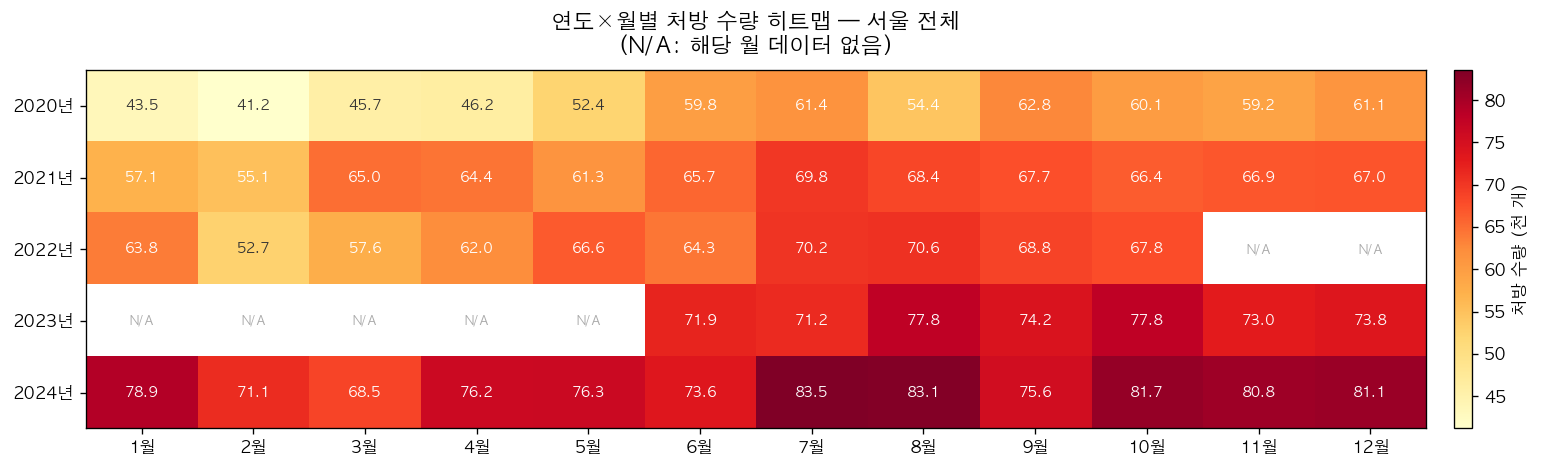

In [10]:
# ── 9. 연도×월 히트맵 — 계절성 + 연간 성장 동시 파악 ────────
# 결측 월(데이터 없음)은 NaN으로 표시
pivot_qty = (
    monthly_total
    .assign(연도=lambda x: x.index.year, 월=lambda x: x.index.month)
    .query('수량 > 0')
    .pivot_table(index='연도', columns='월', values='수량', aggfunc='sum')
)
pivot_qty.columns = [MONTH_KR[m] for m in pivot_qty.columns]

fig, ax = plt.subplots(figsize=(13, 4))
valid_vals = pivot_qty.values[~np.isnan(pivot_qty.values)]
im = ax.imshow(pivot_qty.values / 1e3, cmap='YlOrRd', aspect='auto',
               vmin=valid_vals.min() / 1e3, vmax=valid_vals.max() / 1e3)

ax.set_xticks(range(len(pivot_qty.columns)))
ax.set_xticklabels(pivot_qty.columns, fontsize=10)
ax.set_yticks(range(len(pivot_qty.index)))
ax.set_yticklabels([f'{y}년' for y in pivot_qty.index], fontsize=10)

# 각 셀에 값 표시 (결측은 N/A)
threshold = valid_vals.max() / 1e3 * 0.65
for i in range(pivot_qty.shape[0]):
    for j in range(len(pivot_qty.columns)):
        val = pivot_qty.iloc[i, j]
        if np.isnan(val):
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=7.5, color='#aaa')
        else:
            tc = 'white' if val / 1e3 > threshold else '#333'
            ax.text(j, i, f'{val/1e3:.1f}', ha='center', va='center', fontsize=8.5, color=tc)

plt.colorbar(im, ax=ax, pad=0.02, fraction=0.03, label='처방 수량 (천 개)')
ax.set_title('연도×월별 처방 수량 히트맵 — 서울 전체\n(N/A: 해당 월 데이터 없음)',
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
save_path = OUTPUT_DIR / 'fig4_연도월별_히트맵.png'
plt.savefig(save_path)
print(f'그래프 저장 완료: {save_path}')
plt.show()

---
## 5. 주요 분석 인사이트 요약

In [11]:
# ── 10. 분석 결과 인사이트 요약 출력 ────────────────────────
# 구별 TOP/BOTTOM, 계절 성수기/비수기(계절성 지수), 연도별 성장률
top3_gu = gu_total.nlargest(3)
bot3_gu = gu_total.nsmallest(3)
peak_m  = seasonal['금액'].idxmax()   # 계절성 지수 최대 월
low_m   = seasonal['금액'].idxmin()   # 계절성 지수 최소 월
yoy     = (
    monthly_total
    .assign(연도=lambda x: x.index.year)
    .groupby('연도')['금액']
    .sum()
)

print('=' * 58)
print('  피부염 치료제(D11AH) 서울 처방 데이터 분석 인사이트')
print('=' * 58)
print(f'\n[분석 기간]  2020.01 ~ 2024.12  ({len(month_col_pairs)}개월)')
print(f'[대상 지역]  서울특별시 25개 자치구')
print(f'[ATC 코드]  D11AH — 피부염 치료제 (스테로이드 제외)')

print('\n[구별 처방 금액 TOP 3]')
for rank, (gu, amt) in enumerate(top3_gu.items(), 1):
    print(f'  {rank}위  {gu:<6} {amt/1e8:>6.1f}억원')

print('\n[구별 처방 금액 BOTTOM 3]')
for rank, (gu, amt) in enumerate(bot3_gu.items(), 1):
    print(f'  {rank}위  {gu:<6} {amt/1e8:>6.1f}억원')

# seasonal은 연평균 대비 비율(지수)이므로 억원이 아닌 지수값으로 출력
print(f'\n[계절성 패턴 — 연평균 대비 지수 (1.0 = 연평균)]')
print(f'  처방 성수기 (최대): {peak_m}  지수 {seasonal.loc[peak_m, "금액"]:.3f}')
print(f'  처방 비수기 (최소): {low_m}  지수 {seasonal.loc[low_m, "금액"]:.3f}')

print('\n[연도별 처방 금액 합계 및 전년 대비 성장률]')
prev = None
for yr, amt in yoy.items():
    if prev is not None:
        growth = (amt - prev) / prev * 100
        print(f'  {yr}년: {amt/1e8:>7.1f}억원  ({growth:+.1f}%)')
    else:
        print(f'  {yr}년: {amt/1e8:>7.1f}억원')
    prev = amt

print('\n[저장된 그래프 파일]')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f}')
print('=' * 58)

  피부염 치료제(D11AH) 서울 처방 데이터 분석 인사이트

[분석 기간]  2020.01 ~ 2024.12  (53개월)
[대상 지역]  서울특별시 25개 자치구
[ATC 코드]  D11AH — 피부염 치료제 (스테로이드 제외)

[구별 처방 금액 TOP 3]
  1위  동작구     179.0억원
  2위  서대문구    151.3억원
  3위  중구      144.9억원

[구별 처방 금액 BOTTOM 3]
  1위  도봉구       1.7억원
  2위  금천구       2.2억원
  3위  강북구       3.3억원

[계절성 패턴 — 연평균 대비 지수 (1.0 = 연평균)]
  처방 성수기 (최대): 12월  지수 1.151
  처방 비수기 (최소): 2월  지수 0.778

[연도별 처방 금액 합계 및 전년 대비 성장률]
  2020년:   148.3억원
  2021년:   254.2억원  (+71.4%)
  2022년:   285.6억원  (+12.4%)
  2023년:   296.8억원  (+3.9%)
  2024년:   616.7억원  (+107.8%)

[저장된 그래프 파일]
  output_figures/fig1_구별_처방금액_합계.png
  output_figures/fig2_월별_처방_트렌드.png
  output_figures/fig3_계절성_패턴.png
  output_figures/fig4_연도월별_히트맵.png
